# Autoencoder for dimensionality reduction on scaled Salinity and Temperature (ST) data - GMM clustering

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional
import plotly.express as px
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [3]:
# Get data into dataframe
df = pd.read_csv('../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]']]

In [4]:
# Define random seed for reproducibility
seed = 22

In [5]:
# Scale data
scaler = StandardScaler()
df_ST_scaled = scaler.fit_transform(df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']])

In [6]:
input_dim = df_ST_scaled.shape[1]
latent_dim = 2

# Encoder
inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(16, activation='relu')(inputs)
x = layers.Dense(8, activation='relu')(x)
latent = layers.Dense(latent_dim, name="latent")(x)

# Decoder
x = layers.Dense(8, activation='relu')(latent)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(input_dim)(x)

autoencoder = models.Model(inputs, outputs)
encoder = models.Model(inputs, latent)

In [8]:
autoencoder.compile(
    optimizer='adam',
    loss='mse')

autoencoder.fit(
    df_ST_scaled,
    df_ST_scaled,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=0)

356342/356342 ━━━━━━━━━━━━━━━━━━━━ 203s 569us/step


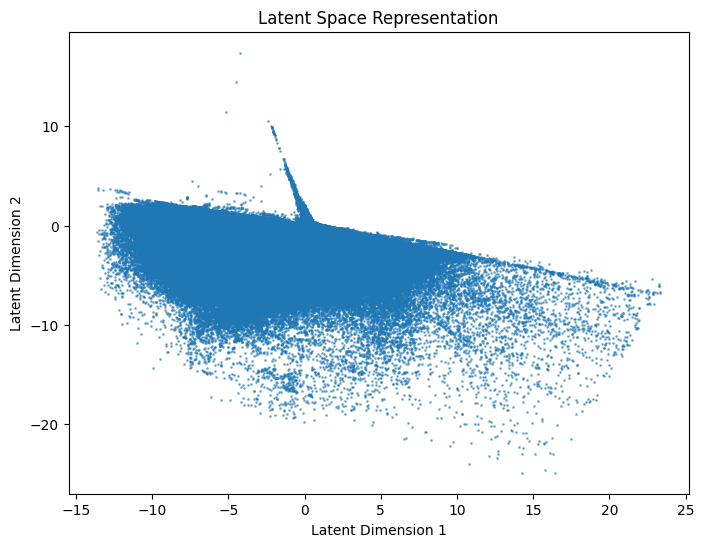

In [9]:
X_latent = encoder.predict(df_ST_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_latent[:,0], X_latent[:,1], s=1, alpha=0.5)
plt.title('Latent Space Representation')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.show()

In [10]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=22)
    gmm.fit(X_latent)
    bic_scores.append(gmm.bic(X_latent))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

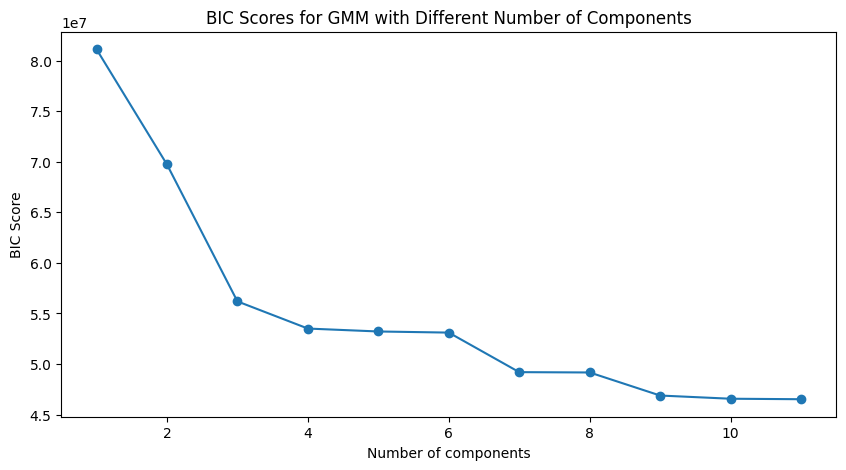

In [11]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [12]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 7

In [13]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(X_latent)

In [14]:
df_ST['gmm_label'] = labels

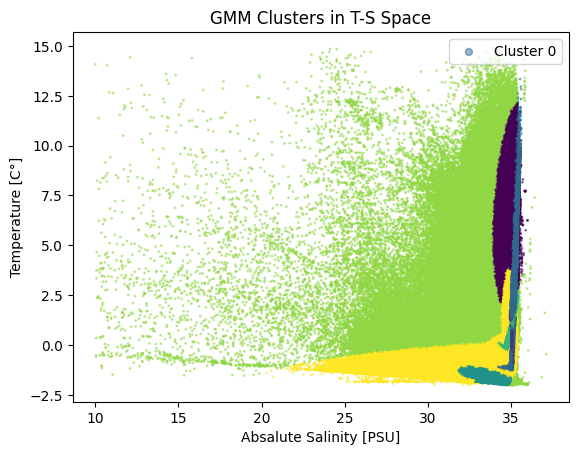

In [15]:
plt.scatter(df_ST['Absolute_Salinity_[PSU]'], df_ST['Conservative_Temperature_[deg_C]'], c=labels, s=1, alpha=0.5)
plt.xlabel("Absalute Salinity [PSU]")
plt.ylabel("Temperature [C°]")
plt.title("GMM Clusters in T-S Space")
#plt.legend(np.unique(labels), loc='upper left', markerscale=5)
plt.legend(loc='upper right', labels=[f'Cluster {i}' for i in range(optimal_n_components)], markerscale=5)
plt.show()

In [16]:
# Sample geographically for better plotting
df_sampled = df_ST.sample(n=100000, random_state=seed)

In [17]:
# Compute data centroid (mean location)
center_lat = df_ST['Latitude_[deg_N]'].mean()
center_lon = df_ST['Longitude_[deg_E]'].mean()

print("Center lat:", center_lat, "Center lon:", center_lon)

# Use labels from kmeans clustering on data to plot geographically
fig = px.scatter_geo(
    df_sampled,
    lat='Latitude_[deg_N]',
    lon='Longitude_[deg_E]',
    color='gmm_label',
    title="Gaussian Mixture Model on TS space on geographic map"
)

fig.update_geos(
    projection_type="orthographic",
    projection_rotation=dict(lat=center_lat, lon=center_lon),
    showcoastlines=True,
    showcountries=True
)

fig.update_layout(height=800, width=800)
fig.show()

Center lat: 76.8460061580696 Center lon: -50.20923396499005


In [18]:
# Plot in 3D
fig_3d = px.scatter_3d(
    df_sampled,
    x='Latitude_[deg_N]',
    y='Longitude_[deg_E]',
    z='Depth_[m]',
    color='gmm_label',
    title="Gaussian Mixture Model clusters on Lat Lon Depth"
)
fig_3d.update_layout(
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Depth (m)',
        zaxis=dict(autorange='reversed')  # Depth increases downwards
    ),
    title="3D Scatter plot of GMM clusters in Geographic space"
)
fig_3d.update_layout(height=800, width=800)
fig_3d.update_traces(marker_size=4)


fig_3d.show()

In [19]:
def cross_sec_lon(lat_value, tol=0.5):
    df_lon_slice = df_ST[(df_ST['Longitude_[deg_E]'] >= lat_value - tol) & (df_ST['Longitude_[deg_E]'] <= lat_value + tol)]
    plt.figure(figsize=(10,6))
    scatter = plt.scatter(
        df_lon_slice['Latitude_[deg_N]'],
        df_lon_slice['Depth_[m]'],
        c=df_lon_slice['gmm_label'],
        s=10,
        alpha=0.7
    )
    plt.gca().invert_yaxis()  # Depth increases downwards
    plt.colorbar(scatter, label='GMM Cluster Label')
    plt.xlabel('Latitude [deg N]')
    plt.ylabel('Depth [m]')
    plt.title(f'GMM Clusters in Latitude-Depth Cross Section at Longitude ~ {lat_value}°E')
    plt.show()

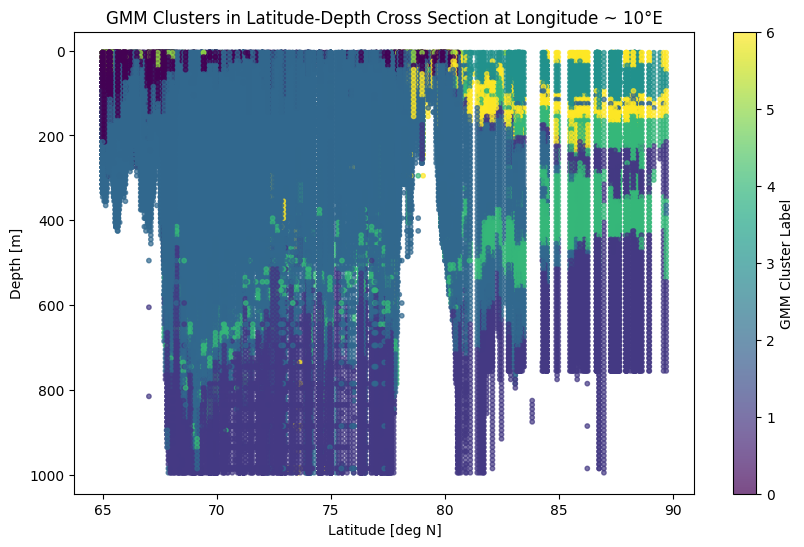

In [20]:
# Plot cross section for specific longitude slice
lon_slice = 10
cross_sec_lon(lon_slice, tol=0.5)